In [3]:
# ── Imports ────────────────────────────────────────────────────────────────
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests  import StockQuotesRequest, StockTradesRequest
from datetime import datetime
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [4]:
# ── Connexion Alpaca & récupération des quotes ─────────────────────────────
# Les clés sont lues depuis les variables d'environnement ()
API_KEY    = os.environ['ALPACA_KEY']
API_SECRET = os.environ['ALPACA_SECRET']

client = StockHistoricalDataClient(API_KEY, API_SECRET)

# Fenêtre de collecte : session de trading du 3 juin 2024 (14h00 – 15h30 UTC)
# feed='iex' → données gratuites IEX (latence ~350 µs, suffisante pour notre analyse)
request_quotes = StockQuotesRequest(
    symbol_or_symbols='AAPL',
    start=datetime(2024, 6, 3, 14, 0),
    end=datetime(2024, 6, 3, 15, 30),
    feed='iex',
)
quotes = client.get_stock_quotes(request_quotes)
df     = quotes.df

# Calcul du spread bid-ask (mesure de la tightness du marché selon Kyle)
df['spread'] = df['ask_price'] - df['bid_price']

df.head()

bid_price  bid_size bid_exchange  \
symbol timestamp                                                            
AAPL   2024-06-03 14:00:00.709414+00:00     191.65       2.0            V   
       2024-06-03 14:00:00.714788+00:00     191.65       2.0            V   
       2024-06-03 14:00:00.731201+00:00     191.65       2.0            V   
       2024-06-03 14:00:00.731823+00:00     191.65       2.0            V   
       2024-06-03 14:00:00.741157+00:00     191.65       2.0            V   

                                         ask_price  ask_size ask_exchange  \
symbol timestamp                                                            
AAPL   2024-06-03 14:00:00.709414+00:00     194.35       1.0            V   
       2024-06-03 14:00:00.714788+00:00     194.35       2.0            V   
       2024-06-03 14:00:00.731201+00:00     194.36       2.0            V   
       2024-06-03 14:00:00.731823+00:00     194.36       1.0            V   
       2024-06-03 14:00:00.741157+00:00     195.00       2.0            V   

                                        conditions tape  spread  
symbol timestamp                                                 
AAPL   2024-06-03 14:00:00.709414+00:00        [R]    C    2.70  
       2024-06-03 14:00:00.714788+00:00        [R]    C    2.70  
       2024-06-03 14:00:00.731201+00:00        [R]    C    2.71  
       2024-06-03 14:00:00.731823+00:00        [R]    C    2.71  
       2024-06-03 14:00:00.741157+00:00        [R]    C    3.35

In [5]:
# ── Récupération des trades tick-by-tick ───────────────────────────────────
# Fenêtre réduite 14h30–15h00 : liquide, représentative de la session continue
request_trades = StockTradesRequest(
    symbol_or_symbols=['AAPL'],
    start='2024-06-03T14:30:00Z',
    end='2024-06-03T15:00:00Z',
)
trades_raw = client.get_stock_trades(request_trades)

# Conversion en DataFrame et indexation par timestamp UTC
trades = pd.DataFrame([t.__dict__ for t in trades_raw['AAPL']])
trades['timestamp'] = pd.to_datetime(trades['timestamp'], utc=True)
trades = trades.set_index('timestamp').sort_index()

trades.head()

,symbol,exchange,price,size,id,conditions,tape
timestamp,,,,,,,
2024-06-03 14:30:00.147035+00:00,AAPL,D,194.8350,10.0,71324,"[@, I]",C
2024-06-03 14:30:00.246607+00:00,AAPL,D,194.8339,80.0,71325,"[@, I]",C
2024-06-03 14:30:00.268994+00:00,AAPL,D,194.8372,1.0,695,"[@, I]",C
2024-06-03 14:30:00.335060+00:00,AAPL,D,194.8400,1.0,71326,"[@, I]",C
2024-06-03 14:30:00.503265+00:00,AAPL,D,194.8385,30.0,71327,"[@, I]",C


In [6]:
# ── Reconstruction du carnet d'ordres sur une fenêtre glissante ────────────

def get_book(df: pd.DataFrame, t: str, window: str = '5min'):
    """
    Reconstitue le carnet d'ordres agrégé sur [t - window, t].

    Paramètres
    ----------
    df     : DataFrame multi-index (symbol, timestamp) retourné par Alpaca.
    t      : Instant de snapshot (str ISO-8601 ou Timestamp).
    window : Largeur de la fenêtre glissante (ex. '5min', '1min').

    Retourne
    --------
    bids, asks : DataFrames triés par prix, avec colonnes
                 ['price', 'size', 'cumulative_depth'].
    """
    # Supprimer le niveau 'symbol' — inutile ici (actif unique : AAPL)
    df_flat = df.xs('AAPL', level='symbol')

    # Délimitation de la fenêtre en UTC
    t       = pd.Timestamp(t, tz='UTC')
    t_start = t - pd.Timedelta(window)
    mask    = (df_flat.index >= t_start) & (df_flat.index <= t)
    df_win  = df_flat[mask]

    # Agrégation des volumes par niveau de prix (bid & ask séparément)
    def aggregate_side(price_col, size_col, ascending):
        return (
            df_win
            .groupby(price_col)[size_col]
            .sum()
            .reset_index()
            .rename(columns={price_col: 'price', size_col: 'size'})
            .sort_values('price', ascending=ascending)
            .reset_index(drop=True)
            .assign(cumulative_depth=lambda x: x['size'].cumsum())
        )

    bids = aggregate_side('bid_price', 'bid_size', ascending=False)
    asks = aggregate_side('ask_price', 'ask_size', ascending=True)

    return bids, asks

/tmp/ipykernel_103060/3267724497.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.90])


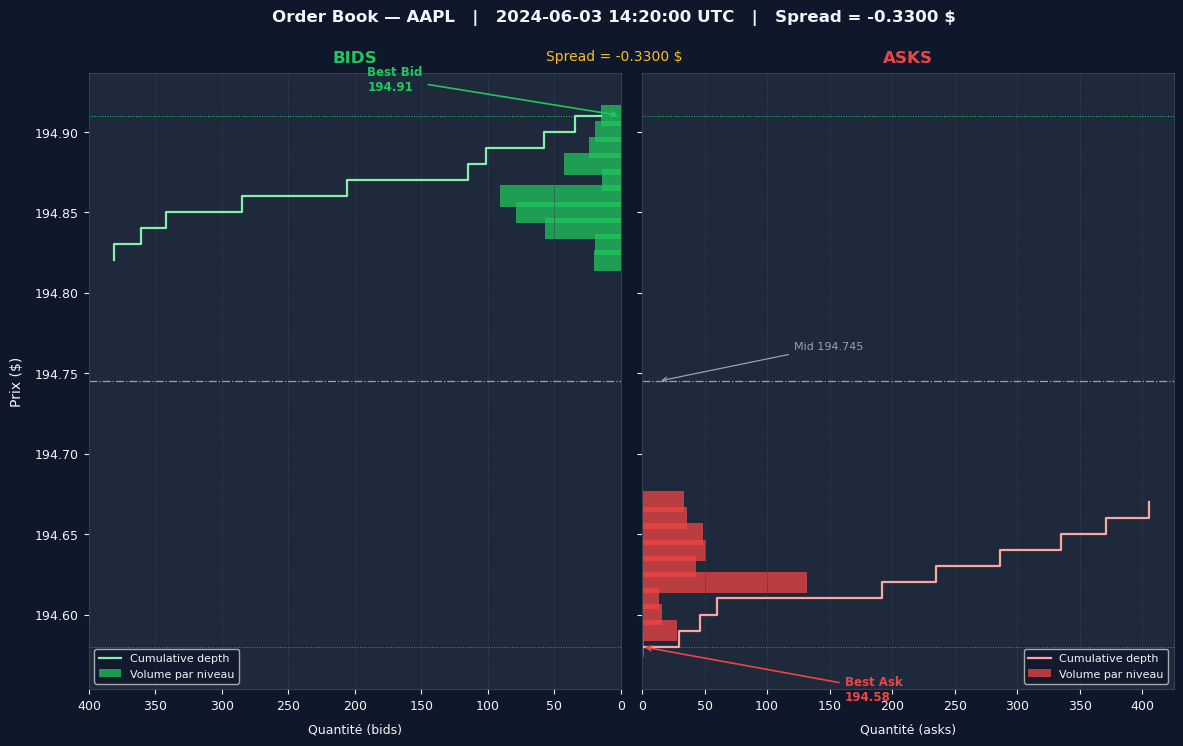

In [7]:
# ── Visualisation du carnet d'ordres ───────────────────────────────────────
SNAPSHOT = '2024-06-03 14:20:00'   # Instant du snapshot
N        = 10                       # Nombre de niveaux de prix affichés

# Palette dark-mode (cohérente avec les conventions : vert=bid, rouge=ask)
BID_COLOR       = '#22c55e'
ASK_COLOR       = '#ef4444'
BID_DEPTH_COLOR = '#86efac'
ASK_DEPTH_COLOR = '#fca5a5'
BG_COLOR        = '#0f172a'
PANEL_COLOR     = '#1e293b'
GRID_COLOR      = '#334155'
TEXT_COLOR      = '#f1f5f9'
MID_COLOR       = '#94a3b8'
SPREAD_COLOR    = '#fbbf24'

bids, asks   = get_book(df, SNAPSHOT)
bids_top     = bids.head(N).copy()
asks_top     = asks.head(N).copy()

best_bid  = bids_top['price'].iloc[0]
best_ask  = asks_top['price'].iloc[0]
spread    = best_ask - best_bid
midprice  = (best_bid + best_ask) / 2

# Hauteur des barres proportionnelle à l'écart de prix total
all_prices  = pd.concat([bids_top['price'], asks_top['price']])
price_range = all_prices.max() - all_prices.min()
bar_height  = price_range / (N * 2.5)

fig, (ax_bid, ax_ask) = plt.subplots(
    1, 2,
    figsize=(14, 8),
    sharey=True,
    gridspec_kw={'wspace': 0.04}
)
fig.patch.set_facecolor(BG_COLOR)

# Axes communs : fond, grille, lignes de référence (best bid/ask, mid)
for ax in (ax_bid, ax_ask):
    ax.set_facecolor(PANEL_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.grid(axis='x', color=GRID_COLOR, linewidth=0.5, linestyle='--')
    ax.axhline(best_bid, color=BID_COLOR, linewidth=0.7, linestyle=':')
    ax.axhline(best_ask, color=ASK_COLOR, linewidth=0.7, linestyle=':')
    ax.axhline(midprice, color=MID_COLOR, linewidth=0.9, linestyle='-.')
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)

# Panel gauche — Bids (volume par niveau + profondeur cumulée)
ax_bid.barh(bids_top['price'], bids_top['size'],
            height=bar_height, color=BID_COLOR, alpha=0.75, label='Volume par niveau')
ax_bid.step(bids_top['cumulative_depth'], bids_top['price'],
            where='post', color=BID_DEPTH_COLOR, linewidth=1.6, label='Cumulative depth')
ax_bid.invert_xaxis()   # Axe X inversé : les bids pointent vers la gauche
ax_bid.yaxis.set_tick_params(labelleft=True)
ax_bid.set_xlabel('Quantité (bids)', color=TEXT_COLOR, fontsize=9, labelpad=8)
ax_bid.set_ylabel('Prix ($)',        color=TEXT_COLOR, fontsize=10, labelpad=8)
ax_bid.tick_params(axis='y', colors=TEXT_COLOR)
ax_bid.set_title('BIDS', color=BID_COLOR, fontsize=12, fontweight='bold', pad=8)
ax_bid.legend(facecolor=BG_COLOR, labelcolor=TEXT_COLOR, fontsize=8, loc='lower left')

# Panel droit — Asks
ax_ask.barh(asks_top['price'], asks_top['size'],
            height=bar_height, color=ASK_COLOR, alpha=0.75, label='Volume par niveau')
ax_ask.step(asks_top['cumulative_depth'], asks_top['price'],
            where='post', color=ASK_DEPTH_COLOR, linewidth=1.6, label='Cumulative depth')
ax_ask.set_xlabel('Quantité (asks)', color=TEXT_COLOR, fontsize=9, labelpad=8)
ax_ask.set_title('ASKS', color=ASK_COLOR, fontsize=12, fontweight='bold', pad=8)
ax_ask.legend(facecolor=BG_COLOR, labelcolor=TEXT_COLOR, fontsize=8, loc='lower right')

# Annotations : best bid, best ask, midprice
ax_bid.annotate(f'Best Bid\n{best_bid:.2f}',
    xy=(0, best_bid),
    xytext=(bids_top['cumulative_depth'].max() * 0.5, best_bid + bar_height * 1.2),
    color=BID_COLOR, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=BID_COLOR, lw=1.2))

ax_ask.annotate(f'Best Ask\n{best_ask:.2f}',
    xy=(0, best_ask),
    xytext=(asks_top['cumulative_depth'].max() * 0.4, best_ask - bar_height * 2.5),
    color=ASK_COLOR, fontsize=8.5, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ASK_COLOR, lw=1.2))

ax_ask.annotate(f'Mid {midprice:.3f}',
    xy=(asks_top['size'].max() * 0.1, midprice),
    xytext=(asks_top['cumulative_depth'].max() * 0.3, midprice + bar_height * 1.5),
    color=MID_COLOR, fontsize=8,
    arrowprops=dict(arrowstyle='->', color=MID_COLOR, lw=0.9))

# Titre global avec spread
spread_color_txt = SPREAD_COLOR if spread < 0 else BID_COLOR
spread_label     = f'Spread = {spread:.4f} $'
fig.text(0.5, 0.96, f'Order Book — AAPL   |   {SNAPSHOT} UTC   |   {spread_label}',
         ha='center', va='top', color=TEXT_COLOR, fontsize=12, fontweight='bold')
fig.text(0.5, 0.91, spread_label,
         ha='center', va='top', color=spread_color_txt, fontsize=10)

# Cadrage de l'axe Y pour laisser de la marge autour des niveaux extrêmes
ax_bid.set_ylim(all_prices.min() - bar_height * 2, all_prices.max() + bar_height * 2)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# Le Modèle de Kyle (1985)

> **Référence :** Kyle, A.S. (1985). *Continuous Auctions and Insider Trading*. **Econometrica**, 53(6), 1315–1335.

---

## 1. Structure du modèle

Kyle (1985) est le modèle fondateur de la microstructure moderne. Il pose un cadre d'**information asymétrique** avec trois types d'agents interagissant sur un marché à enchères continues :

| Agent | Rôle | Information |
|---|---|---|
|  **Insider** (informé) | Choisit sa quantité $x$ stratégiquement | Observe la valeur fondamentale $\tilde{v}$ |
|  **Noise Traders** (non informés) | Génèrent un flux exogène $u$ | Aucune — trading aléatoire |
|  **Market Maker** (teneur de marché) | Fixe le prix $P$ en zéro-profit | Observe uniquement le flux agrégé $y = x + u$ |

**Hypothèses du modèle :**
- L'actif a une valeur de liquidation $\tilde{v} \sim \mathcal{N}(p_0,\ \sigma_v^2)$
- Les noise traders génèrent un flux $u \sim \mathcal{N}(0,\ \sigma_u^2)$, indépendant de $\tilde{v}$
- Le market maker est en **concurrence zéro-profit** : il fixe $P = \mathbb{E}[\tilde{v} \mid y]$

---

## 2. L'équilibre linéaire

Kyle démontre l'existence d'un **unique équilibre linéaire**. La règle de pricing du market maker est :

$$\boxed{P(y) = p_0 + \lambda \cdot y}$$

où $y = x + u$ est le flux d'ordres net agrégé et $\lambda$ est le **lambda de Kyle** (impact de marché).

La **stratégie optimale de l'insider** est également linéaire :

$$x^* = \beta \cdot (\tilde{v} - p_0), \qquad \beta = \frac{\sigma_u}{\sigma_v}$$

---

## 3. Le Lambda de Kyle — Mesure de l'impact de marché

Le lambda de Kyle est la pierre angulaire du modèle :

$$\lambda = \frac{\sigma_v}{2\,\sigma_u}$$

**Interprétation :** $\lambda$ mesure la **sensibilité du prix au flux d'ordres** — combien de dollars le prix se déplace par unité de volume tradé.

$$\Delta P = \lambda \cdot \Delta y$$

| Valeur de $\lambda$ | Marché | Intuition |
|---|---|---|
| $\lambda$ **élevé** | Illiquide, peu profond | Chaque ordre déplace fortement le prix |
| $\lambda$ **faible** | Liquide, profond | Les ordres ont un faible impact prix |

**Déterminants de $\lambda$ :**

| Facteur | Effet sur $\lambda$ | Intuition |
|---|---|---|
| ↑ Incertitude fondamentale $\sigma_v$ | ↑ $\lambda$ | Plus d'asymétrie d'information potentielle |
| ↑ Volume noise traders $\sigma_u$ | ↓ $\lambda$ | L'insider se camoufle mieux dans le flux |
| ↑ Nombre d'insiders en compétition | ↓ $\lambda$ | La rente informationnelle se dissipe |

---

## 4. Propriétés clés du modèle

**① Révélation partielle d'information**
L'insider *fractionne* ses ordres sur l'horizon de trading pour préserver sa rente informationnelle. Le prix converge progressivement vers $\tilde{v}$, sans révélation instantanée.

**② Impact entièrement permanent**
Dans la version mono-période, tout le déplacement de prix est permanent — il reflète l'information révélée. Il n'existe *pas* de composante de réversion (contrairement aux modèles avec noise).

**③ Profondeur constante**
La profondeur du marché $1/\lambda$ est constante dans la version continue. Les teneurs de marché fournissent de la liquidité à un prix linéaire uniforme.

**④ Rythme optimal d'exécution**
L'insider exécute à un *rythme uniforme* — c'est sa stratégie optimale pour dissimuler son information tout en l'exploitant au maximum.

---

## 5. Les trois dimensions de la liquidité (Kyle 1985)

Kyle identifie trois dimensions orthogonales de la liquidité de marché :

$$\text{Liquidité} = \begin{cases} \textbf{Tightness} & \text{(Étroitesse) — mesuré par le bid-ask spread} \\ \textbf{Depth} & \text{(Profondeur) — volume sans déplacer le prix} \approx \frac{1}{\lambda} \\ \textbf{Resilience} & \text{(Résilience) — vitesse de retour à l'équilibre après un choc} \end{cases}$$

### Market Depth

$$\text{Depth} = \frac{1}{\lambda} = \frac{2\,\sigma_u}{\sigma_v}$$

Empiriquement, $\lambda$ est estimé par la **régression de Hasbrouck** :

$$\Delta p_t = \lambda \cdot x_t + \varepsilon_t$$

où $x_t$ est le flux d'ordres net signé (positif pour les achats, négatif pour les ventes).

### Market Resilience

La résilience $\rho$ est le **taux de retour vers la valeur fondamentale** après un choc non-informationnel. Elle est liée à la demi-vie du choc de prix :

$$t_{1/2} = \frac{\ln 2}{\rho}$$

| | Résilience forte | Résilience faible |
|---|---|---|
| Spread | Se referme rapidement | Reste écarté longtemps |
| Carnet d'ordres | Se reconstitue vite | Liquidité absente durablement |
| Impact | Essentiellement temporaire | Très persistant |
| Typique | Marchés matures, large caps | Marchés émergents, small caps |

---

## 6. Application empirique sur les données AAPL

Dans la suite, on utilise les données de carnet d'ordres AAPL (3 juin 2024) pour **estimer empiriquement** $\lambda$ via la régression de Hasbrouck, et mesurer les trois dimensions de la liquidité de Kyle à haute fréquence.

In [8]:
# ── Reconstruction du mid-price tick-by-tick ────────────────────────────────
# Le mid-price est la référence neutre entre bid et ask.
# Il sert de proxy de la valeur fondamentale dans le modèle de Kyle.
df_aapl = df.xs('AAPL', level='symbol').copy()
df_aapl['mid'] = (df_aapl['ask_price'] + df_aapl['bid_price']) * 0.5

## Classification des trades — Algorithme de Lee & Ready (1991)

L'algorithme de Lee & Ready classe chaque trade comme **acheteur initié** (+1) ou **vendeur initié** (−1). C'est un prérequis pour calculer le flux d'ordres net $x_t$ utilisé dans la régression de Hasbrouck.

### Règle 1 — Quote Midpoint Rule
Si le prix du trade est **au-dessus du mid** → acheteur initié (il accepte l'ask).  
Si le prix est **en-dessous du mid** → vendeur initié (il accepte le bid).

> **Intuition :** Un acheteur pressé paie proche de l'ask (au-dessus du mid) ; un vendeur pressé accepte proche du bid (en-dessous du mid).

### Règle 2 — Tick Rule (tie-breaker)
En cas d'ambiguïté (trade exactement au mid) : si le prix monte → achat, si le prix baisse → vente.

> **Intuition :** Le mouvement du prix révèle qui a pris l'initiative. Un acheteur agressif fait monter le prix en consommant les offres disponibles.

### Limite
Sur les marchés modernes (dark pools, internalization), les trades au mid sont fréquents, ce qui réduit la fiabilité du tie-breaker par tick.

In [9]:
# ── Classification Lee & Ready & calcul du flux d'ordres net ───────────────

def get_mid_at(t: pd.Timestamp, df_quotes: pd.DataFrame) -> float:
    """
    Retourne le dernier mid-price disponible avant ou à l'instant t.
    Utilise une recherche backward (asof) sur l'index trié.
    """
    mask = df_quotes.index <= t
    return df_quotes.loc[mask, 'mid'].iloc[-1] if mask.any() else np.nan


def classify_trade(trade_price: float, mid_at_trade: float) -> int:
    """
    Algorithme de Lee & Ready (1991) — Quote Midpoint Rule.

    Retourne
    --------
    +1  : trade acheteur initié (trade_price > mid)
    -1  : trade vendeur initié  (trade_price < mid)
     0  : indéterminé           (trade_price == mid, tick rule non implémentée)
    """
    if   trade_price > mid_at_trade: return  1
    elif trade_price < mid_at_trade: return -1
    else:                            return  0


# Associer le mid-price le plus récent à chaque trade, puis classifier
trades['mid_at_trade'] = trades.index.map(lambda t: get_mid_at(t, df_aapl))
trades['direction']    = trades.apply(
    lambda r: classify_trade(r['price'], r['mid_at_trade']), axis=1
)

# Retirer les trades indéterminés (au mid) pour la suite de l'analyse
clean_trades = trades[trades['direction'] != 0].copy()

print(f"Trades totaux : {len(trades):,}  |  Classifiés : {len(clean_trades):,}  "
      f"({len(clean_trades)/len(trades):.1%})")

Trades totaux : 100,188  |  Classifiés : 97,462  (97.3%)


In [10]:
# ── Price Impact à plusieurs horizons τ ────────────────────────────────────
# L'impact est mesuré en points de base (bps) pour être indépendant du niveau de prix.
# Impact signé : positif si le prix évolue dans le sens du trade (cohérent avec Kyle).

HORIZONS = [3, 9, 18]   # Horizons en secondes


def compute_price_impact(trade_time, direction, df_quotes, horizons):
    """
    Calcule l'impact de prix signé à chaque horizon τ.

    Impact(τ) = direction × (mid(t+τ) − mid(t)) / mid(t) × 10 000  [bps]

    Retourne un dict {tau: impact_bps}.
    """
    mid_0 = get_mid_at(trade_time, df_quotes)
    if pd.isna(mid_0) or mid_0 == 0:
        return {tau: np.nan for tau in horizons}

    return {
        tau: direction * (get_mid_at(trade_time + pd.Timedelta(seconds=tau), df_quotes) - mid_0)
             / mid_0 * 10_000
        for tau in horizons
    }


impacts   = clean_trades.apply(
    lambda r: compute_price_impact(r.name, r['direction'], df_aapl, HORIZONS), axis=1
)
impact_df = pd.DataFrame(impacts.tolist(), index=clean_trades.index)
impact_df.columns = [f'impact_{h}s' for h in HORIZONS]

impact_df.describe().round(4)

,impact_3s,impact_9s,impact_18s
count,97462.0000,97462.0000,97462.0000
mean,3.4294,4.9601,5.7658
std,8.1368,9.8834,11.1630
min,-26.9480,-26.9604,-29.0145
25%,-0.2571,-0.5156,-1.0300
50%,0.2575,1.8005,3.3488
75%,6.6850,11.0475,14.1326
max,31.5992,32.5967,34.1490


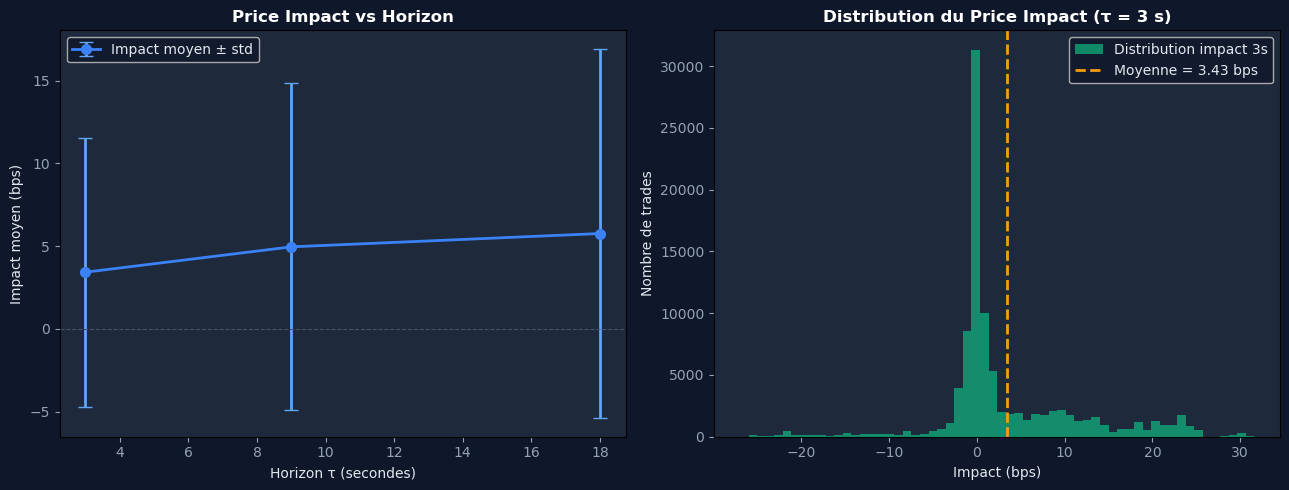

In [11]:
# ── Visualisation du price impact ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0f172a')

# Panel gauche — Impact moyen ± écart-type par horizon τ
ax = axes[0]
ax.set_facecolor('#1e293b')

mean_impacts = [impact_df[f'impact_{h}s'].mean() for h in HORIZONS]
std_impacts  = [impact_df[f'impact_{h}s'].std()  for h in HORIZONS]

ax.errorbar(HORIZONS, mean_impacts, yerr=std_impacts,
            fmt='o-', color='#3b82f6', linewidth=2,
            ecolor='#60a5fa', capsize=5, markersize=7,
            label='Impact moyen ± std')
ax.axhline(0, color='#475569', linewidth=0.8, linestyle='--')
ax.set_xlabel('Horizon τ (secondes)', color='#e2e8f0')
ax.set_ylabel('Impact moyen (bps)',   color='#e2e8f0')
ax.set_title('Price Impact vs Horizon', color='white', fontweight='bold')
ax.tick_params(colors='#94a3b8')
ax.legend(facecolor='#0f172a', labelcolor='#e2e8f0')

# Panel droit — Distribution des impacts à l'horizon le plus court (τ = 3 s)
ax2 = axes[1]
ax2.set_facecolor('#1e293b')

data_3s = impact_df['impact_3s'].dropna()   # τ = 3 s

ax2.hist(data_3s, bins=60, color='#10b981', alpha=0.7,
         edgecolor='none', label='Distribution impact 3s')
ax2.axvline(data_3s.mean(), color='#f59e0b', linewidth=2,
            linestyle='--', label=f'Moyenne = {data_3s.mean():.2f} bps')
ax2.set_xlabel('Impact (bps)',        color='#e2e8f0')
ax2.set_ylabel('Nombre de trades',   color='#e2e8f0')
ax2.set_title('Distribution du Price Impact (τ = 3 s)', color='white', fontweight='bold')
ax2.tick_params(colors='#94a3b8')
ax2.legend(facecolor='#0f172a', labelcolor='#e2e8f0')

plt.tight_layout()
plt.savefig('price_impact_aapl.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Estimation du lambda de Kyle via la régression de Hasbrouck ────────────
# Modèle : ∆mid(t, τ) = λ · signed_volume(t) + ε
# signed_volume = size × direction (+achat / -vente)

HORIZON = 3   # secondes — horizon de mesure du déplacement de prix


def compute_delta_mid(t, df_quotes, horizon):
    """Variation du mid-price entre t et t + horizon (en dollars)."""
    mid_0   = get_mid_at(t, df_quotes)
    mid_tau = get_mid_at(t + pd.Timedelta(seconds=horizon), df_quotes)
    return mid_tau - mid_0 if not (pd.isna(mid_0) or pd.isna(mid_tau)) else np.nan


clean_trades['signed_volume'] = clean_trades['size'] * clean_trades['direction']
clean_trades['delta_mid']     = clean_trades.index.map(
    lambda t: compute_delta_mid(t, df_aapl, HORIZON)
)

# OLS sans intercept (le modèle de Kyle suppose E[∆mid] = 0 sans flux)
mask = clean_trades[['signed_volume', 'delta_mid']].notna().all(axis=1)
X    = clean_trades.loc[mask, 'signed_volume'].values
Y    = clean_trades.loc[mask, 'delta_mid'].values

slope, intercept, r_val, p_val, std_err = linregress(X, Y)

# Conversion en bps/action pour faciliter la comparaison inter-actifs
mean_mid    = clean_trades['mid_at_trade'].mean()
lambda_kyle = slope / mean_mid * 10_000
r_squared   = r_val ** 2

print(f"λ de Kyle estimé  : {lambda_kyle:.4f} bps / action")
print(f"R²                : {r_squared:.4f}")
print(f"p-value           : {p_val:.4e}")

# ── Profondeur de marché ─────────────────────────────────────────────────────
# Depth = 1/λ → volume (en actions) déplaçant le prix d'un bps
depth = 1 / lambda_kyle
print(f"\nProfondeur de marché (1/λ) : {depth:.2f} actions / bps")

λ de Kyle estimé  : 0.0044 bps / action
R²                : 0.0091
p-value           : 3.1959e-196

Profondeur de marché (1/λ) : 229.81 actions / bps


## Indicateurs de Microstructure Avancés

---

### 1. VWAP Horaire (Volume-Weighted Average Price)

$$\text{VWAP}_h = \frac{\sum_{t \in h} P_t \cdot V_t}{\sum_{t \in h} V_t}$$

Le VWAP est le **prix moyen pondéré par le volume** sur une fenêtre horaire. C'est la référence benchmark de l'exécution institutionnelle : un algorithme qui exécute *en dessous* du VWAP (pour un achat) est considéré comme performant.

| Valeur | Interprétation |
|--------|----------------|
| Prix trade **< VWAP** | Exécution favorable (achat sous le prix moyen de marché) |
| Prix trade **> VWAP** | Exécution défavorable (achat au-dessus du prix moyen) |
| VWAP **croissant** en intraday | Pression acheteuse dominante sur la session |

> **Usage clé :** Détecter les déviations intraday du prix par rapport au VWAP révèle des phases de pression directionnelle et aide à identifier les fenêtres d'exécution optimales.

---

### 2. Trade Imbalance (Déséquilibre acheteur / vendeur)

$$\text{Imbalance} = \frac{V_{\text{buy}} - V_{\text{sell}}}{V_{\text{buy}} + V_{\text{sell}}} \in [-1, +1]$$

Le *trade imbalance* mesure la **pression nette directionnelle** sur le flux d'ordres. Il est directement lié au flux d'ordres $x_t$ du modèle de Kyle.

| Valeur | Interprétation |
|--------|----------------|
| Proche de **+1** | Forte pression acheteuse — les acheteurs initient la majorité des trades |
| Proche de **−1** | Forte pression vendeuse |
| Proche de **0** | Marché équilibré, pas de signal directionnel clair |

> **Lien Kyle :** Un imbalance élevé correspond à un flux $x_t$ fort, ce qui se traduit par un $\lambda$ élevé et un impact de prix plus marqué.

---



In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# VWAP Horaire | Trade Imbalance
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.gridspec as gridspec


# 1. VWAP HORAIRE

trades_vwap = clean_trades.copy()
trades_vwap['dv'] = trades_vwap['price'] * trades_vwap['size']   # dollar-volume par trade

vwap_hourly = trades_vwap.resample('1h').apply(
    lambda g: g['dv'].sum() / g['size'].sum() if g['size'].sum() > 0 else np.nan
).rename('vwap')

mid_hourly = df_aapl['mid'].resample('1h').mean()

print('____________________Vwap_________________________')
print(pd.DataFrame({'VWAP': vwap_hourly, 'Mid moyen': mid_hourly}).dropna().round(4))


# 2. TRADE IMBALANCE (Buy Vol vs Sell Vol)

trades_vwap['buy_vol']  = trades_vwap['size'].where(trades_vwap['direction'] ==  1, 0)
trades_vwap['sell_vol'] = trades_vwap['size'].where(trades_vwap['direction'] == -1, 0)

imbalance_hourly = trades_vwap.resample('1h').apply(
    lambda g: (g['buy_vol'].sum() - g['sell_vol'].sum()) /
              (g['buy_vol'].sum() + g['sell_vol'].sum())
    if (g['buy_vol'].sum() + g['sell_vol'].sum()) > 0 else np.nan
).rename('imbalance')

buy_vol_h  = trades_vwap['buy_vol'].resample('1h').sum()
sell_vol_h = trades_vwap['sell_vol'].resample('1h').sum()

print("\n____ Trade Imbalance Horaire_______________________")
print(pd.DataFrame({
    'Buy Vol':   buy_vol_h,
    'Sell Vol':  sell_vol_h,
    'Imbalance': imbalance_hourly.round(4)
}).dropna())



____________________Vwap_________________________
                               VWAP  Mid moyen
timestamp                                     
2024-06-03 14:00:00+00:00  194.4716   194.4721

____ Trade Imbalance Horaire_______________________
                             Buy Vol   Sell Vol  Imbalance
timestamp                                                 
2024-06-03 14:00:00+00:00  2059538.0  1679558.0     0.1016
